In [1]:
import sys 
sys.path.append("../src")
from data_loader import load_prices , load_returns , compute_hedge_ratio , compute_spread

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

prices = load_prices()
log_returns = load_returns()

# reconstruct spreads
beta_MA_V, intercept_MA_V = compute_hedge_ratio(prices,"MA","V")
beta_GS_MS, intercept_GS_MS = compute_hedge_ratio(prices , "GS" , "MS")

spread_MA_V = compute_spread(prices , "MA", "V" , beta_MA_V , intercept_MA_V)
spread_GS_MS = compute_spread(prices , "GS","MS" , beta_GS_MS , intercept_GS_MS)

print("Spreads ready")
print("MA/V beta: " , round(beta_MA_V,4))
print("GS/MS beta: " , round(beta_GS_MS,4))

Spreads ready
MA/V beta:  1.8669
GS/MS beta:  3.3518


In [2]:
# compute z-score

def compute_zscore(spread,window = 60):
    rolling_mean = spread.rolling(window).mean()
    rolling_std = spread.rolling(window).std()
    zscore = (spread - rolling_mean) / rolling_std
    return zscore

zscore_MA_V = compute_zscore(spread_MA_V)
zscore_GS_MS = compute_zscore(spread_GS_MS)

print("MA/V zscore stats: ")
print(f"  Mean : {zscore_MA_V.mean():.4f}")
print(f"  Std  : {zscore_MA_V.std():.4f}")
print(f"  Min  : {zscore_MA_V.min():.4f}")
print(f"  Max  : {zscore_MA_V.max():.4f}")

MA/V zscore stats: 
  Mean : -0.0205
  Std  : 1.3205
  Min  : -3.9315
  Max  : 4.7452


In [3]:
""" 
Why should mean be ~0 and std be ~1 for a properly computed z-score?

A z-score is a standardised value. By subtracting the mean and dividing by std, you're converting the spread into a universal scale where:

Mean = 0 means the spread is at its average level
Std = 1 means one unit of z-score = one standard deviation

This standardisation lets you set fixed thresholds like ±2 that work for any pair regardless of the spread's actual dollar value.
 MA/V spread has std of $9, GS/MS has std of $13 — but both use the same ±2 z-score threshold because z-score removes the scale difference.
"""

" \nWhy should mean be ~0 and std be ~1 for a properly computed z-score?\n\nA z-score is a standardised value. By subtracting the mean and dividing by std, you're converting the spread into a universal scale where:\n\nMean = 0 means the spread is at its average level\nStd = 1 means one unit of z-score = one standard deviation\n\nThis standardisation lets you set fixed thresholds like ±2 that work for any pair regardless of the spread's actual dollar value.\n MA/V spread has std of $9, GS/MS has std of $13 — but both use the same ±2 z-score threshold because z-score removes the scale difference.\n"

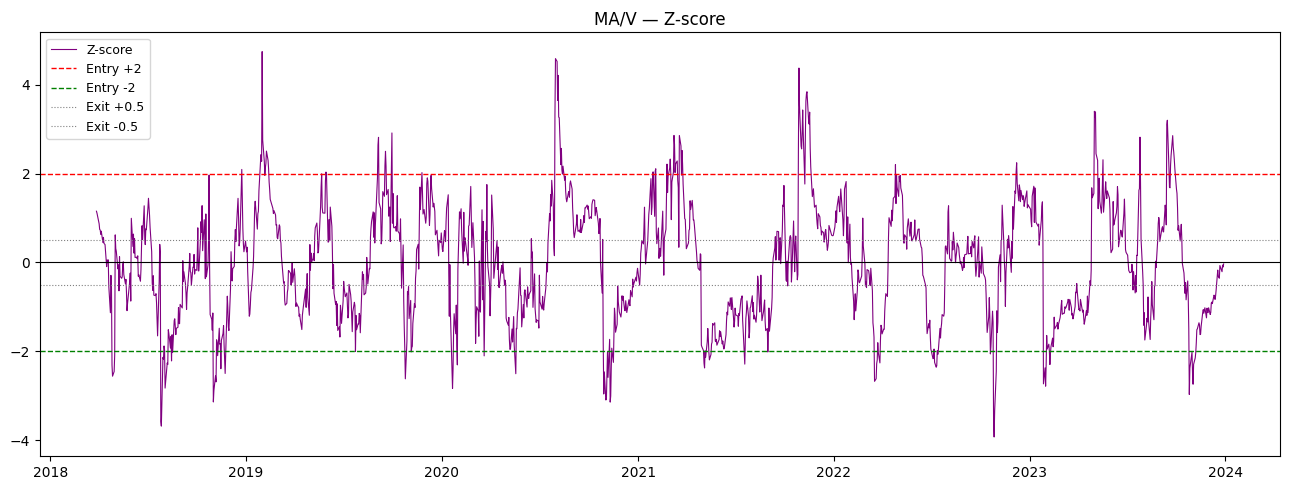

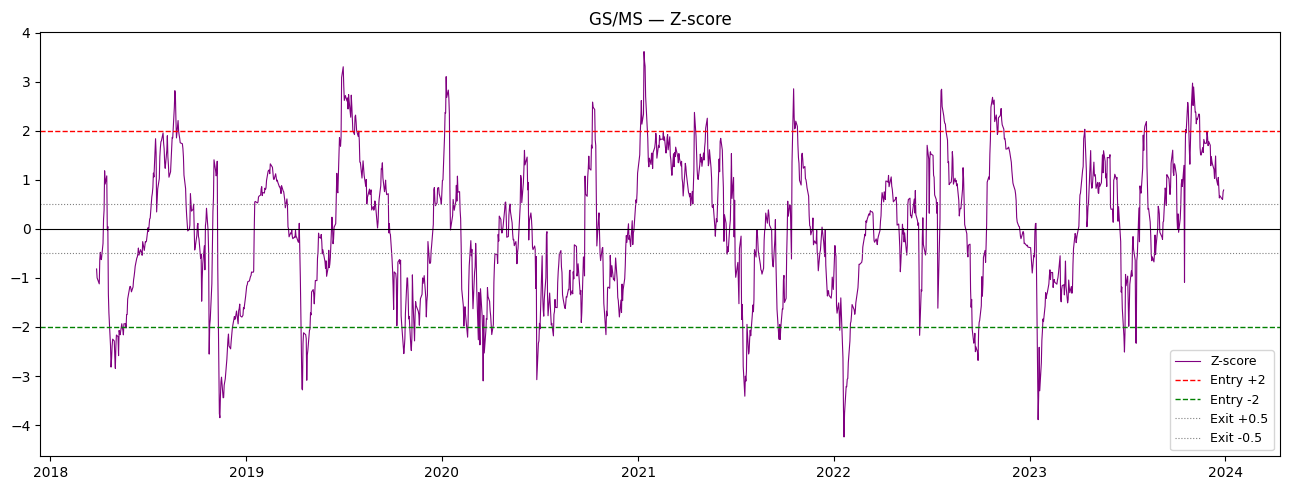

In [4]:
def plot_zscore(zscore, pair_name):
    fig, ax = plt.subplots(figsize=(13, 5))
    
    ax.plot(zscore.index, zscore, color="purple", linewidth=0.8, label="Z-score")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
    ax.axhline(2, color="red", linewidth=1, linestyle="--", label="Entry +2")
    ax.axhline(-2, color="green", linewidth=1, linestyle="--", label="Entry -2")
    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle=":", label="Exit +0.5")
    ax.axhline(-0.5, color="gray", linewidth=0.8, linestyle=":", label="Exit -0.5")
    
    ax.set_title(f"{pair_name} — Z-score")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f"../data/zscore_{pair_name.replace('/', '_')}.png", dpi=120)
    plt.show()

plot_zscore(zscore_MA_V, "MA/V")
plot_zscore(zscore_GS_MS, "GS/MS")

In [5]:
# generate trading signals

def generate_signals(zscore , entry = 2.0 , exit = 0.5) :
    signals = pd.Series(0, index = zscore.index)
    position = 0

    for i in range(len(zscore)):
        z = zscore.iloc[i]

        if pd.isna(z) : 
            signals.iloc[i] = 0
            continue

        # entry logic 
        if position == 0:
            if z > entry:
                position = -1   # short spread
            elif z < -entry:
                position = 1    # long spread

        # exit logic
        elif position == 1:
            if z > -exit:
                position = 0    # close long
            
        elif position == -1:
            if z < exit:
                position = 0    # close short

        signals.iloc[i] = position

    return signals

signals_MA_V = generate_signals(zscore_MA_V)
signals_GS_MS = generate_signals(zscore_GS_MS)

print("MA/V signals count: ")
print(signals_MA_V.value_counts())

MA/V signals count: 
 0    905
 1    326
-1    278
Name: count, dtype: int64


In [6]:
""" 
Signal = 1 means long spread = MA − β×V is unusually low (z < −2), so MA is cheap relative to V:

Long MA — buy the cheap one
Short V — sell the expensive one

Signal = −1 means short spread = MA − β×V is unusually high (z > +2), so MA is expensive relative to V:

Short MA — sell the expensive one
Long V — buy the cheap one
"""

' \nSignal = 1 means long spread = MA − β×V is unusually low (z < −2), so MA is cheap relative to V:\n\nLong MA — buy the cheap one\nShort V — sell the expensive one\n\nSignal = −1 means short spread = MA − β×V is unusually high (z > +2), so MA is expensive relative to V:\n\nShort MA — sell the expensive one\nLong V — buy the cheap one\n'

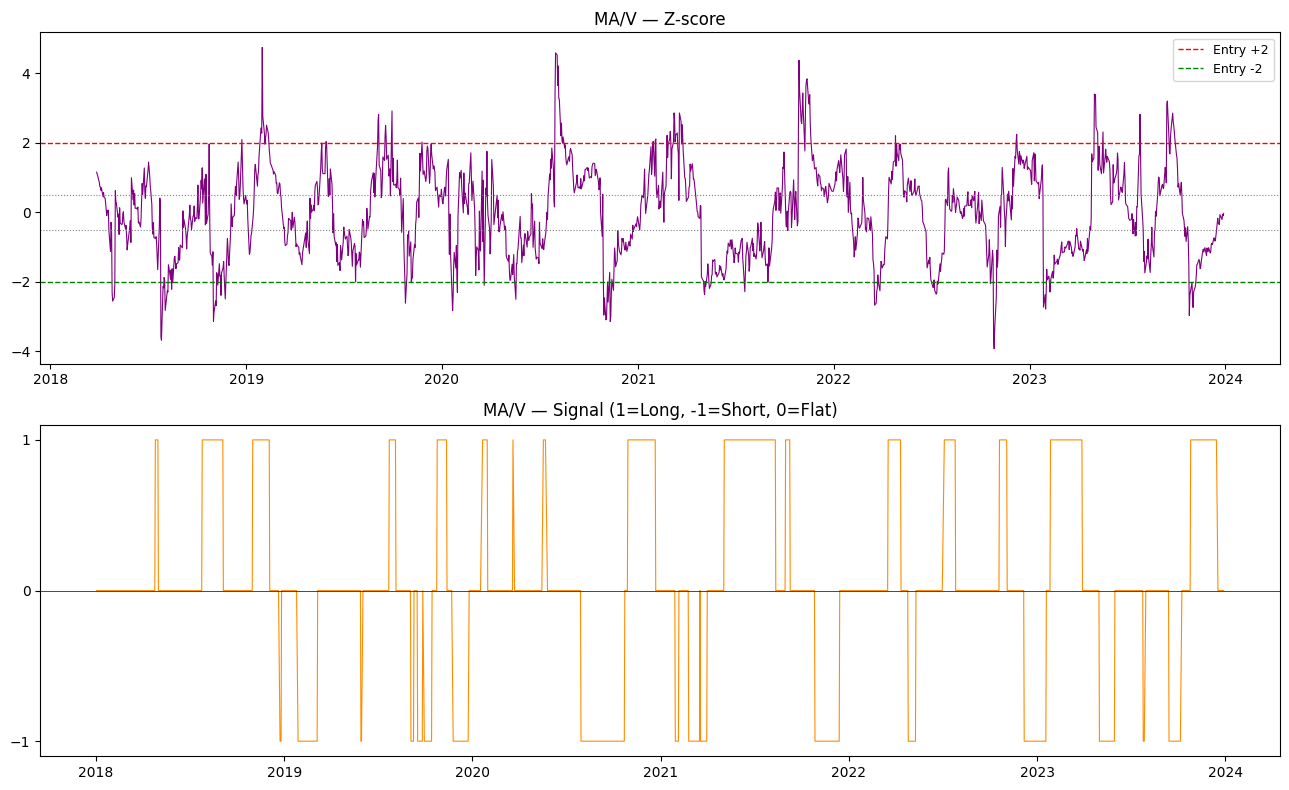

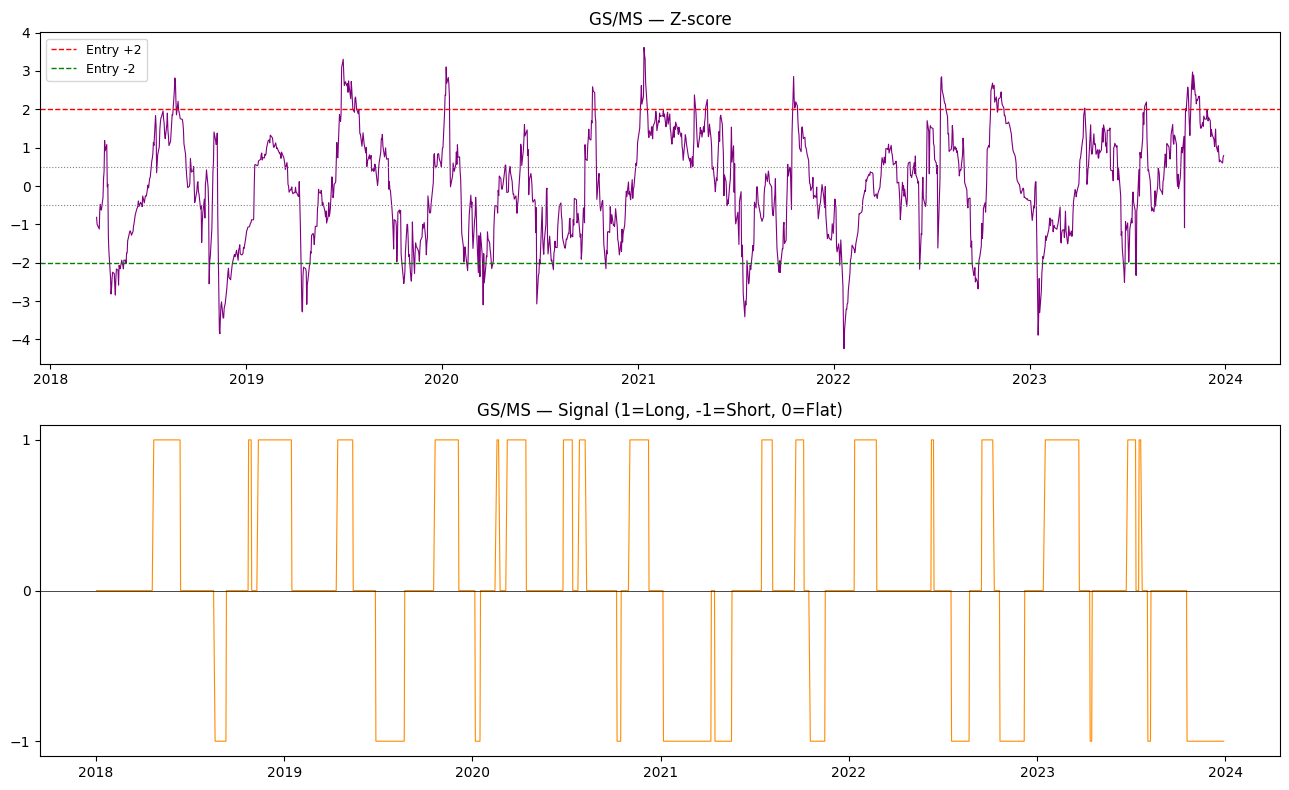

In [7]:
def plot_signals(zscore, signals, pair_name):
    fig, axes = plt.subplots(2, 1, figsize=(13, 8))
    
    # top - zscore with entry/exit lines
    axes[0].plot(zscore.index, zscore, color="purple", linewidth=0.8)
    axes[0].axhline(2, color="red", linewidth=1, linestyle="--", label="Entry +2")
    axes[0].axhline(-2, color="green", linewidth=1, linestyle="--", label="Entry -2")
    axes[0].axhline(0.5, color="gray", linewidth=0.8, linestyle=":")
    axes[0].axhline(-0.5, color="gray", linewidth=0.8, linestyle=":")
    axes[0].set_title(f"{pair_name} — Z-score")
    axes[0].legend(fontsize=9)
    
    # bottom - signal
    axes[1].plot(signals.index, signals, color="darkorange", linewidth=0.8)
    axes[1].axhline(0, color="black", linewidth=0.5)
    axes[1].set_title(f"{pair_name} — Signal (1=Long, -1=Short, 0=Flat)")
    axes[1].set_yticks([-1, 0, 1])
    
    plt.tight_layout()
    plt.savefig(f"../data/signals_{pair_name.replace('/', '_')}.png", dpi=120)
    plt.show()

plot_signals(zscore_MA_V, signals_MA_V, "MA/V")
plot_signals(zscore_GS_MS, signals_GS_MS, "GS/MS")

In [8]:
def trade_stats(signals , pair_name):
    # a new trade starts when signal changes from 0 to non-zero
    entries = ((signals != 0) & (signals.shift(1) == 0)).sum()
    exits = ((signals == 0) & (signals.shift(1) != 0)).sum()

    long_days = (signals == 1).sum()
    short_days = (signals == -1).sum()
    flat_days = (signals == 0).sum()

    print(f"{pair_name} Trade Stats:")
    print(f"  Total entries   : {entries}")
    print(f"  Total exits      : {exits}")
    print(f"  Long days        : {long_days}")
    print(f"  Short days       : {short_days}")
    print(f"  Flat days        : {flat_days}")
    print()


trade_stats(signals_MA_V,"MA/V")
trade_stats(signals_GS_MS , "GS/MS")

MA/V Trade Stats:
  Total entries   : 33
  Total exits      : 34
  Long days        : 326
  Short days       : 278
  Flat days        : 905

GS/MS Trade Stats:
  Total entries   : 30
  Total exits      : 30
  Long days        : 352
  Short days       : 290
  Flat days        : 867



In [9]:
signals = pd.DataFrame({
    "MA/V" : signals_MA_V,
    "GS/MS" : signals_GS_MS
})

signals.to_parquet("../data/signals.parquet")
verify = pd.read_parquet("../data/signals.parquet")
print(verify.shape)
print(verify.value_counts())

(1509, 2)
MA/V  GS/MS
 0     0       529
       1       220
-1     0       208
 0    -1       156
 1     0       130
       1       113
      -1        83
-1    -1        51
       1        19
Name: count, dtype: int64


In [10]:
from data_loader import compute_zscore, generate_signals

zscore = compute_zscore(spread_MA_V)
signals = generate_signals(zscore)
print(signals.value_counts())

 0    905
 1    326
-1    278
Name: count, dtype: int64
